Cilj projekta je sljedeci: da li mozemo na osnovu tehnickih karakteristika racunarskog sistema da predvidimo njegovu performansu?

Na osnovu web stranice na kojoj se nalazi dataset, receno je da za svaku kolonu nema nedostajucih vrijednosti, sto bi tehnicki trebalo da olaksa ciscenje podataka.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("data/machine.data", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9
0,adviser,32/60,125,256,6000,256,16,128,198,199
1,amdahl,470v/7,29,8000,32000,32,8,32,269,253
2,amdahl,470v/7a,29,8000,32000,32,8,32,220,253
3,amdahl,470v/7b,29,8000,32000,32,8,32,172,253
4,amdahl,470v/7c,29,8000,16000,32,8,16,132,132


Vidimo da ovi podaci dolaze bez headera, te su nazivi kolona 0, 1, 2, ..., 9 umjesto korektnih naziva, te se to treba promjeniti.

In [12]:
kolone = ["VendorName", "ModelName", "MYCT", "MMIN", "MMAX", "CACH", "CHMIN", "CHMAX", "PRP", "ERP"]

df.columns = kolone
df.head()

,VendorName,ModelName,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX,PRP,ERP
0,adviser,32/60,125,256,6000,256,16,128,198,199
1,amdahl,470v/7,29,8000,32000,32,8,32,269,253
2,amdahl,470v/7a,29,8000,32000,32,8,32,220,253
3,amdahl,470v/7b,29,8000,32000,32,8,32,172,253
4,amdahl,470v/7c,29,8000,16000,32,8,16,132,132


Prilikom analize podataka, IDE je oznacio "1 dataset issue", cime je oznacio prisustvo outliera u vise numerickih atributa ("MYCT", "MMIN", "CACH", "CHMIN", "CHMAX"). Nakon dodatne analize, zakljuceno je da ove vrijednosti vjerovatno predstavljaju stvarne ekstremne konfiguracije hardvera, ne gresku pri unosu podataka. Zbog toga ce ovi outlieri ostati i njihova uloga ce se dodatno analizirati kroz performanse modela.

In [35]:
print("Dimenzije: ", df.shape)
print()
print(df.info())
print()
print(df.describe(include="all"))

Dimenzije:  (209, 10)

<class 'pandas.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   VendorName  209 non-null    str  
 1   ModelName   209 non-null    str  
 2   MYCT        209 non-null    int64
 3   MMIN        209 non-null    int64
 4   MMAX        209 non-null    int64
 5   CACH        209 non-null    int64
 6   CHMIN       209 non-null    int64
 7   CHMAX       209 non-null    int64
 8   PRP         209 non-null    int64
 9   ERP         209 non-null    int64
dtypes: int64(8), str(2)
memory usage: 16.5 KB
None

       VendorName ModelName         MYCT          MMIN          MMAX  \
count         209       209   209.000000    209.000000    209.000000   
unique         30       209          NaN           NaN           NaN   
top           ibm     32/60          NaN           NaN           NaN   
freq           32         1          NaN           NaN           NaN   
me

In [36]:
print("Nedostajuce vrijednosti po kolonama:")
print(df.isnull().sum())
print("Broj duplikata: ", df.duplicated().sum())

Nedostajuce vrijednosti po kolonama:
VendorName    0
ModelName     0
MYCT          0
MMIN          0
MMAX          0
CACH          0
CHMIN         0
CHMAX         0
PRP           0
ERP           0
dtype: int64
Broj duplikata:  0


In [38]:
print(df.nunique())

VendorName     30
ModelName     209
MYCT           60
MMIN           25
MMAX           23
CACH           22
CHMIN          15
CHMAX          31
PRP           116
ERP           104
dtype: int64

              MYCT          MMIN          MMAX        CACH       CHMIN  \
count   209.000000    209.000000    209.000000  209.000000  209.000000   
mean    203.822967   2867.980861  11796.153110   25.205742    4.698565   
std     260.262926   3878.742758  11726.564377   40.628722    6.816274   
min      17.000000     64.000000     64.000000    0.000000    0.000000   
25%      50.000000    768.000000   4000.000000    0.000000    1.000000   
50%     110.000000   2000.000000   8000.000000    8.000000    2.000000   
75%     225.000000   4000.000000  16000.000000   32.000000    6.000000   
max    1500.000000  32000.000000  64000.000000  256.000000   52.000000   

            CHMAX          PRP          ERP  
count  209.000000   209.000000   209.000000  
mean    18.267943   105.622010    99.330144  
s

Dakle, dataset sadrzi 209 redova i 10 atributa. Atributi VendorNaame i ModelName su kategorijalni. Atributi MYCT, MMIN, MMAX, CACH, CHMIN, CHMAX, PRP, ERP su numericki. Provjerom je utvrdjeno da dataset nema nedostajucih vrijednosti te je potvrdjeno da nema duplikata. Sada se moze trenirati model. Prema ciljnoj varijabli PRP.

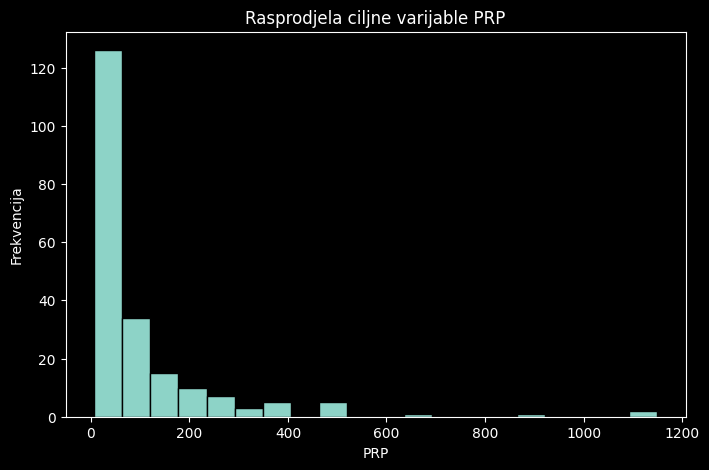

In [39]:
plt.figure(figsize=(8, 5))
plt.hist(df["PRP"], bins=20, edgecolor="black")
plt.title("Rasprodjela ciljne varijable PRP")
plt.xlabel("PRP")
plt.ylabel("Frekvencija")
plt.show()

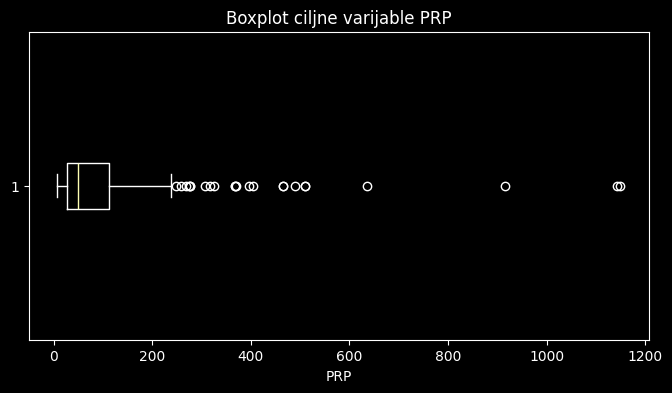

In [40]:
plt.figure(figsize=(8, 4))
plt.boxplot(df["PRP"], vert=False)
plt.title("Boxplot ciljne varijable PRP")
plt.xlabel("PRP")
plt.show()

In [41]:
numeric_df = df.select_dtypes(include=[np.number])

corr = numeric_df.corr()
print(corr["PRP"].sort_values(ascending=False))

PRP      1.000000
ERP      0.966472
MMAX     0.863004
MMIN     0.794931
CACH     0.662641
CHMIN    0.608903
CHMAX    0.605209
MYCT    -0.307099
Name: PRP, dtype: float64


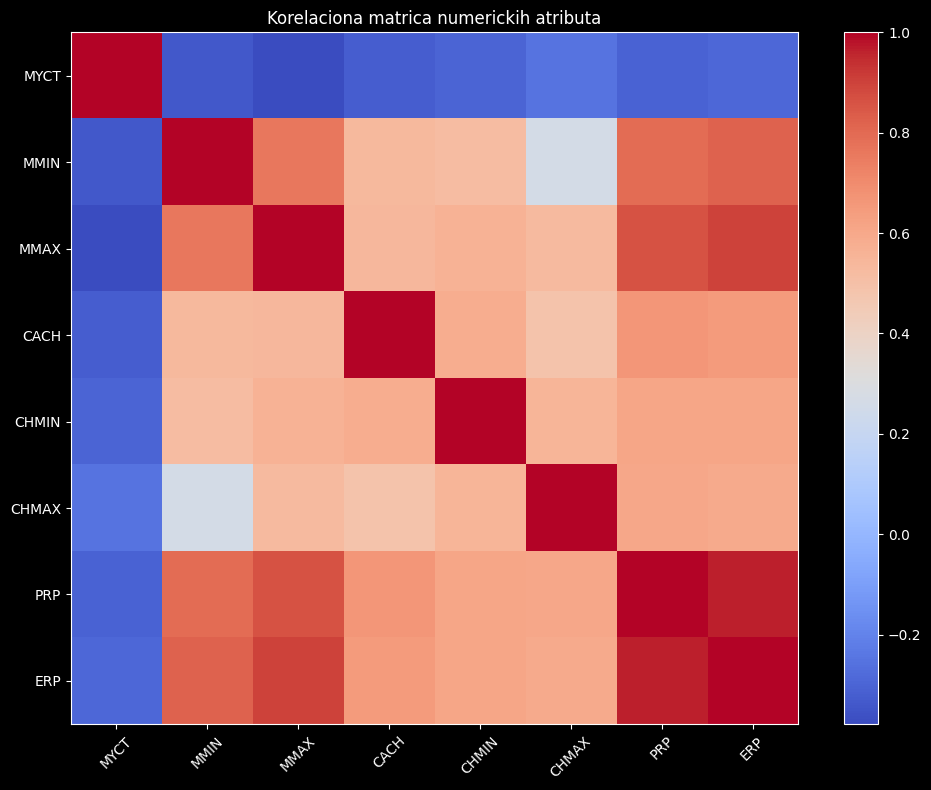

In [46]:
plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Korelaciona matrica numerickih atributa")
plt.tight_layout()
plt.show()

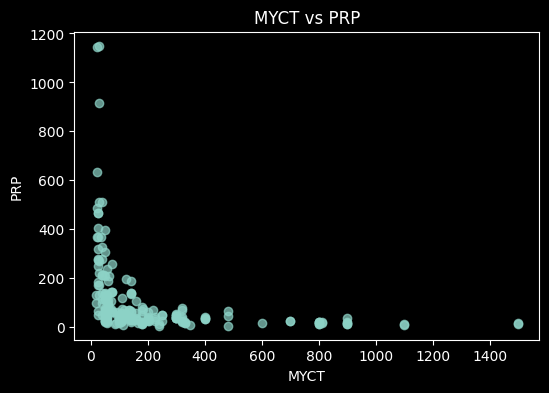

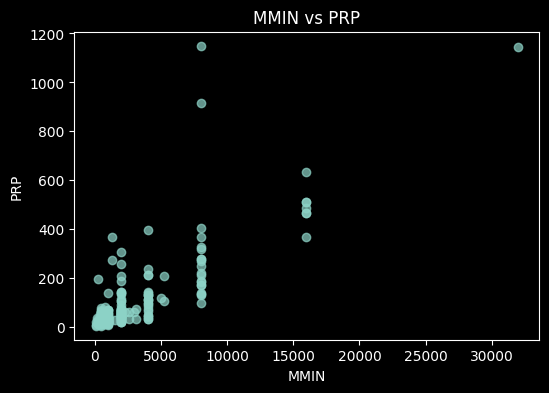

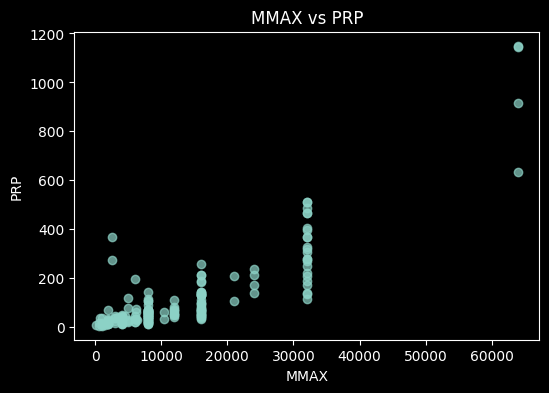

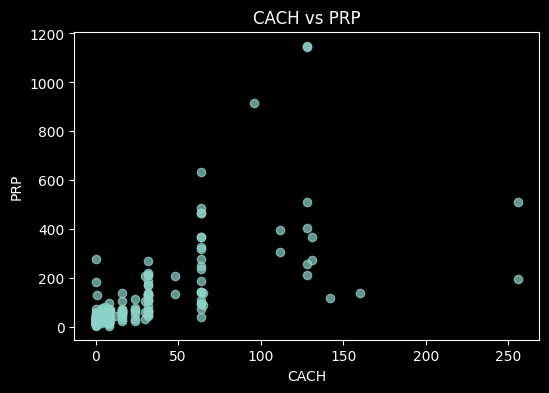

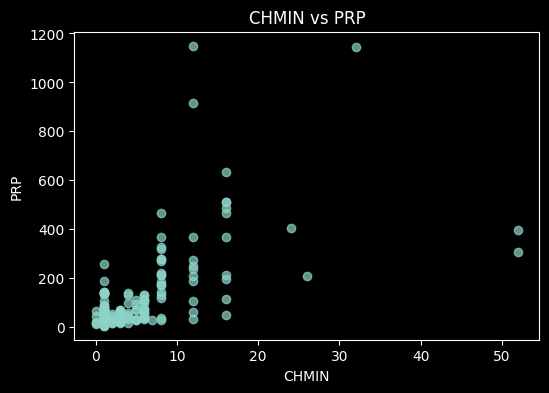

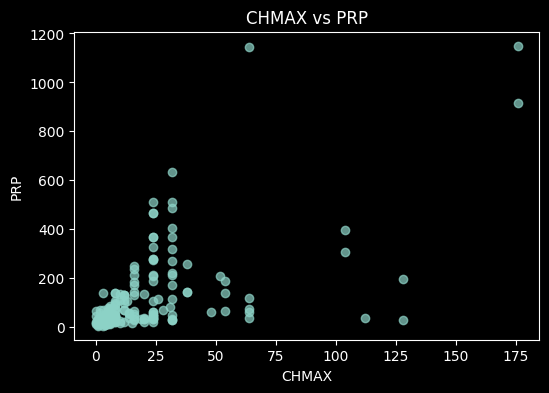

In [47]:
numericke_kolone = ["MYCT", "MMIN", "MMAX", "CACH", "CHMIN", "CHMAX"]

for kol in numericke_kolone:
    plt.figure(figsize=(6,4))
    plt.scatter(df[kol], df["PRP"], alpha=0.7)
    plt.title(f"{kol} vs PRP")
    plt.xlabel(kol)
    plt.ylabel("PRP")
    plt.show()

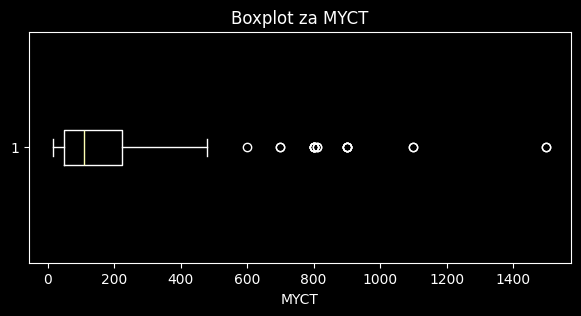

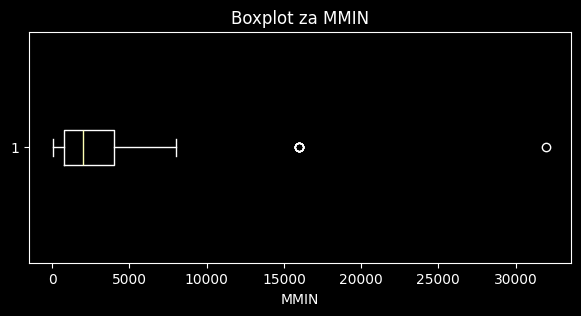

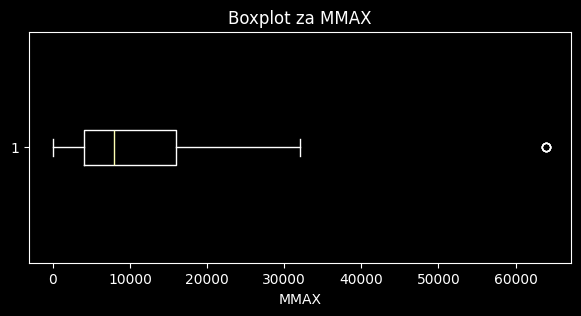

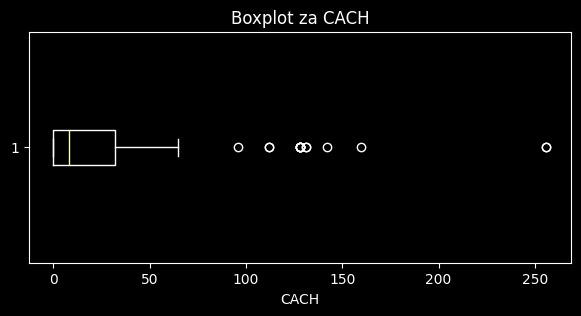

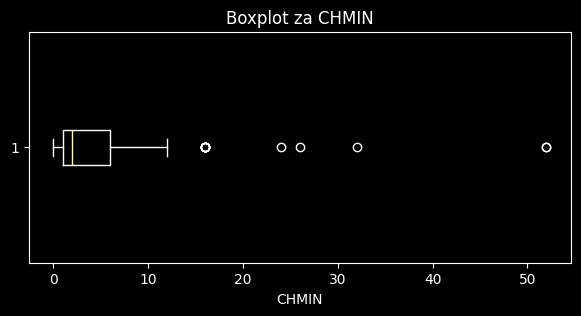

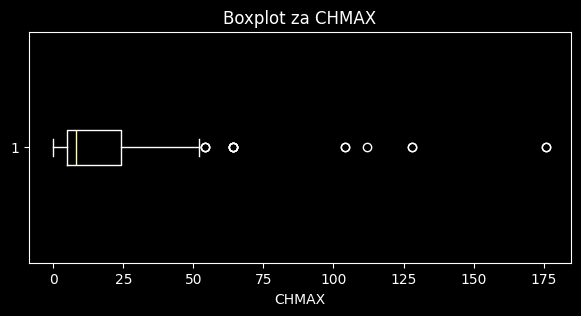

In [48]:
for kol in numericke_kolone:
    plt.figure(figsize=(7,3))
    plt.boxplot(df[kol], vert=False)
    plt.title(f"Boxplot za {kol}")
    plt.xlabel(kol)
    plt.show()